# YZ50 Hafta 7: Self-Attention

Karpathy, *Let's build GPT* videosunun ilk 1 saat 22 dakikası. Veri: Tiny Shakespeare (`input.txt`).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(1337)

## Görev 1: Veri, tokenizer, get_batch ve bigram tabanı

In [2]:
text = open('input.txt', 'r', encoding='utf-8').read()
print("karakter sayısı:", len(text))
print(text[:250])

karakter sayısı: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



In [3]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print("vocab_size:", vocab_size)

stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for i,ch in enumerate(chars)}
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

print(encode("hii there"))
print(decode(encode("hii there")))


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab_size: 65
[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


In [4]:
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)

n = int(0.9*len(data))
train_data = data[:n]
val_data = data[n:]
print("train:", len(train_data), "val:", len(val_data))

torch.Size([1115394]) torch.int64
train: 1003854 val: 111540


In [5]:
block_size = 8
batch_size = 32

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print(xb.shape, yb.shape)
# bir satırdaki 8 örnek: bağlam büyüdükçe hedef değişiyor
for t in range(block_size):
    context = xb[0, :t+1]
    target = yb[0, t]
    print(f"girdi {context.tolist()} -> hedef {target.item()}")

torch.Size([32, 8]) torch.Size([32, 8])
girdi [24] -> hedef 43
girdi [24, 43] -> hedef 58
girdi [24, 43, 58] -> hedef 5
girdi [24, 43, 58, 5] -> hedef 57
girdi [24, 43, 58, 5, 57] -> hedef 1
girdi [24, 43, 58, 5, 57, 1] -> hedef 46
girdi [24, 43, 58, 5, 57, 1, 46] -> hedef 43
girdi [24, 43, 58, 5, 57, 1, 46, 43] -> hedef 39


In [6]:
@torch.no_grad()
def estimate_loss(model, eval_iters=200):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

def train(model, max_iters, lr, eval_interval=1000):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    for it in range(max_iters):
        if it % eval_interval == 0 or it == max_iters - 1:
            l = estimate_loss(model)
            print(f"adım {it:5d}: train {l['train']:.4f}, val {l['val']:.4f}")
        xb, yb = get_batch('train')
        _, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
    return estimate_loss(model)

In [7]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # her token bir sonraki tokenın logitlerini doğrudan tablodan okur
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)  # (B,T,C)
        if targets is None:
            return logits, None
        B, T, C = logits.shape
        loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, _ = self(idx)
            probs = F.softmax(logits[:, -1, :], dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

torch.manual_seed(1337)
bigram = BigramLanguageModel(vocab_size)
print("başlangıç loss beklentisi -ln(1/65) =", round(-torch.log(torch.tensor(1/vocab_size)).item(), 4))
bigram_losses = train(bigram, max_iters=10000, lr=1e-2)
bigram_val = bigram_losses['val']
print("BIGRAM val loss:", round(bigram_val, 4))

başlangıç loss beklentisi -ln(1/65) = 4.1744


adım     0: train 4.7305, val 4.7241


adım  1000: train 2.4879, val 2.5192


adım  2000: train 2.4714, val 2.4913


adım  3000: train 2.4610, val 2.4869


...

adım  6000: train 2.4528, val 2.4922


adım  7000: train 2.4612, val 2.4893


adım  8000: train 2.4538, val 2.4863


adım  9000: train 2.4601, val 2.4952


adım  9999: train 2.4644, val 2.4690
BIGRAM val loss: 2.4764


In [8]:
print(decode(bigram.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=300)[0].tolist()))


I e.
KEThof arno treit miecoh! m, erinst flawhant fe ere bons thand athe it gome-OR f: in, he spoth,
Me, adalee ist s:
In ol it gllinde me h chid oug--ccas hed as o tot thit anceth ESen y man s s e dere CH: sotis,
Furayomust.
ALAnden one encos wes thyownd lds l w'dsedeanllaper l ghire r hend:
Thioik


## Görev 2: Geçmişin ortalaması, üç yol

In [9]:
torch.manual_seed(1337)
B, T, C = 4, 8, 2
x = torch.randn(B, T, C)

# yol 1: for döngüsü
xbow = torch.zeros((B, T, C))
for b in range(B):
    for t in range(T):
        xprev = x[b, :t+1]          # (t+1, C)
        xbow[b, t] = torch.mean(xprev, 0)

# yol 2: alt üçgen matrisle çarpım
wei = torch.tril(torch.ones(T, T))
wei = wei / wei.sum(1, keepdim=True)
xbow2 = wei @ x                     # (T,T) @ (B,T,C) -> (B,T,C)

# yol 3: softmax
tril = torch.tril(torch.ones(T, T))
wei3 = torch.zeros((T, T))
wei3 = wei3.masked_fill(tril == 0, float('-inf'))
wei3 = F.softmax(wei3, dim=-1)
xbow3 = wei3 @ x

print("döngü == tril:   ", torch.allclose(xbow, xbow2))
print("döngü == softmax:", torch.allclose(xbow, xbow3))
print(wei3)

döngü == tril:    True
döngü == softmax: True
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])


In [10]:
# küçük bir örnekle matris çarpımının ağırlıklı ortalama olduğunu görmek
torch.manual_seed(42)
a = torch.tril(torch.ones(3, 3))
a = a / a.sum(1, keepdim=True)
b = torch.randint(0, 10, (3, 2)).float()
print("a=\n", a)
print("b=\n", b)
print("a@b=\n", a @ b)

a=
 tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
b=
 tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
a@b=
 tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


**Matris çarpımı neden ağırlıklı ortalama?**

`c = a @ b` çarpımında `c`'nin t. satırı, `b`'nin bütün satırlarının toplamıdır ve her satır `a[t]`'deki sayıyla çarpılır: `c[t] = a[t,0]*b[0] + a[t,1]*b[1] + ...`. Yani `a`'nın her satırı "hangi satırdan ne kadar alayım" diyen bir ağırlık listesi.

`a`'nın her satırının toplamı 1 olursa bu toplama ağırlıklı ortalama olur. `tril` ile üst üçgeni sıfırlayınca t. satır sadece 0..t arasındaki satırlara ağırlık verir, yani her token sadece kendisinin ve geçmişin ortalamasını alır, geleceğe bakmaz. Yukarıdaki örnekte `a@b`'nin 2. satırı `b`'nin ilk iki satırının ortalaması, 3. satırı üç satırın ortalaması.

Softmax yolu aynı şeyi yapıyor: maskelenen yerlere `-inf` yazıyoruz, `exp(-inf)=0` olduğu için oralar sıfır ağırlık alıyor, geri kalanlar eşitse softmax hepsine eşit pay veriyor. Bu yolun avantajı, ağırlıkları sıfır yerine veriden gelen skorlarla doldurabilmemiz. Self-attention'da tam olarak bunu yapacağız: ortalama eşit değil, token'lar arasındaki benzerliğe göre olacak.

## Görev 3: Tek bir self-attention head

In [11]:
torch.manual_seed(1337)
B, T, C = 4, 8, 32
x = torch.randn(B, T, C)

head_size = 16
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x)      # (B,T,16)  "ben neyim"
q = query(x)    # (B,T,16)  "ben ne arıyorum"
wei = q @ k.transpose(-2, -1) * head_size**-0.5   # (B,T,16) @ (B,16,T) -> (B,T,T)

tril = torch.tril(torch.ones(T, T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)    # (B,T,16)  "bana bakarsan sana bunu veririm"
out = wei @ v   # (B,T,16)
print("k", k.shape, "q", q.shape, "wei", wei.shape, "out", out.shape)
torch.set_printoptions(precision=3, sci_mode=False)
print(wei[0])

k torch.Size([4, 8, 16]) q torch.Size([4, 8, 16]) wei torch.Size([4, 8, 8]) out torch.Size([4, 8, 16])
tensor([[1.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000],
        [0.397, 0.603, 0.000, 0.000, 0.000, 0.000, 0.000, 0.000],
        [0.307, 0.289, 0.404, 0.000, 0.000, 0.000, 0.000, 0.000],
        [0.323, 0.218, 0.244, 0.215, 0.000, 0.000, 0.000, 0.000],
        [0.148, 0.203, 0.166, 0.146, 0.337, 0.000, 0.000, 0.000],
        [0.126, 0.249, 0.132, 0.106, 0.314, 0.072, 0.000, 0.000],
        [0.160, 0.199, 0.114, 0.112, 0.142, 0.167, 0.106, 0.000],
        [0.084, 0.120, 0.108, 0.154, 0.109, 0.115, 0.156, 0.155]],
       grad_fn=<SelectBackward0>)


In [12]:
row = wei[0, -1]
print("son token (t=7) geçmişe şöyle bakıyor:")
for t, w in enumerate(row.tolist()):
    print(f"  t={t}: {w:.3f}  " + "#" * int(w * 60))
print("toplam:", round(row.sum().item(), 4))

son token (t=7) geçmişe şöyle bakıyor:
  t=0: 0.084  #####
  t=1: 0.120  #######
  t=2: 0.108  ######
  t=3: 0.154  #########
  t=4: 0.109  ######
  t=5: 0.115  ######
  t=6: 0.156  #########
  t=7: 0.155  #########
toplam: 1.0


**Bir satırı okumak.** `wei[0]`'ın her satırı bir token'ın, her sütunu baktığı token'ın. Satır t'de t'den sonraki sütunlar 0 çünkü maske geleceği kapatıyor, satır toplamı da 1 çünkü softmax'tan geçti. Ağırlıklar artık eşit değil: t=7'deki token'ın query'si hangi token'ın key'iyle en büyük iç çarpımı veriyorsa en çok ona bakıyor ve çıktısı o token'ın value'sundan en büyük payı alıyor. Burada x rastgele olduğu için ağırlıkların anlamı yok; anlamlı ağırlıklar için eğitilmiş modele aşağıda (Ek a) bakıyoruz.

İlk satır (t=0) hep `[1, 0, 0, ...]`: ilk token'ın bakabileceği tek yer kendisi.

### Neden `head_size**-0.5` ile çarpıyoruz?

q ve k birim varyanslıysa, `q·k` iç çarpımı `head_size` tane terimin toplamı, yani varyansı yaklaşık `head_size` olur. Ölçeklemeden softmax'a büyük sayılar girer ve softmax tek bir değere kilitlenir (neredeyse one-hot). Bu durumda her token sadece tek bir token'a bakar ve gradyanlar çok küçülür.

In [13]:
torch.manual_seed(0)
k = torch.randn(B, T, head_size)
q = torch.randn(B, T, head_size)
w_raw = q @ k.transpose(-2, -1)
w_scaled = w_raw * head_size**-0.5
print("k.var:", round(k.var().item(), 3), " q.var:", round(q.var().item(), 3))
print("bölmeden  wei.var:", round(w_raw.var().item(), 3))
print("bölerek   wei.var:", round(w_scaled.var().item(), 3))

k.var: 1.032  q.var: 1.081
bölmeden  wei.var: 19.014
bölerek   wei.var: 1.188


In [14]:
torch.manual_seed(3)
s = torch.randn(8) * 0.5    # bir satırın skorları
print("skor x1 (bölerek)  :", F.softmax(s, dim=-1))
print("skor x4 (sqrt(16)) :", F.softmax(s * head_size**0.5, dim=-1))   # head_size=16 -> sqrt=4
print("skor x8            :", F.softmax(s * 8, dim=-1))

# eğitilmiş-öncesi bir head'in son satırı, bölmeden ve bölerek
row_raw = w_raw[0, -1]
print()
print("bölmeden softmax:", F.softmax(row_raw, dim=-1))
print("bölerek  softmax:", F.softmax(row_raw * head_size**-0.5, dim=-1))
print("max ağırlık -> bölmeden:", round(F.softmax(row_raw, -1).max().item(), 3),
      " bölerek:", round(F.softmax(row_raw * head_size**-0.5, -1).max().item(), 3))

skor x1 (bölerek)  : tensor([0.171, 0.125, 0.120, 0.084, 0.117, 0.058, 0.136, 0.190])
skor x4 (sqrt(16)) : tensor([0.268, 0.076, 0.064, 0.016, 0.059, 0.003, 0.106, 0.407])
skor x8            : tensor([0.275, 0.022, 0.016, 0.001, 0.013, 0.000, 0.043, 0.631])

bölmeden softmax: tensor([0.513, 0.020, 0.150, 0.020, 0.017, 0.279, 0.002, 0.000])
bölerek  softmax: tensor([0.232, 0.103, 0.171, 0.103, 0.099, 0.199, 0.061, 0.033])
max ağırlık -> bölmeden: 0.513  bölerek: 0.232


Bölmeden varyans `head_size` (16) civarında, bölünce 1'e iniyor. Softmax çıktısında fark açıkça görünüyor: ölçeklenmemiş skorlarda ağırlığın neredeyse tamamı tek bir token'a gidiyor, ölçeklenmiş skorlarda birden fazla token'a dağılıyor. Başlangıçta dağınık ağırlık istiyoruz ki model birçok token'dan bilgi toplayabilsin ve hangisinin önemli olduğunu eğitimle öğrensin.

## Görev 4: Head'i bigram modelinin içine koy

In [15]:
n_embd = 32
block_size = 8

class Head(nn.Module):
    def __init__(self, head_size, causal=True):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.causal = causal
        self.last_wei = None

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * k.shape[-1]**-0.5   # (B,T,T)
        if self.causal:
            wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        self.last_wei = wei.detach()
        v = self.value(x)
        return wei @ v

class SingleHeadModel(nn.Module):
    def __init__(self, causal=True):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.sa_head = Head(n_embd, causal=causal)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)                  # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T))   # (T,C)
        x = tok_emb + pos_emb
        x = self.sa_head(x)
        logits = self.lm_head(x)                                   # (B,T,vocab)
        if targets is None:
            return logits, None
        B, T, C = logits.shape
        loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]   # pozisyon tablosu sadece block_size satır
            logits, _ = self(idx_cond)
            probs = F.softmax(logits[:, -1, :], dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

torch.manual_seed(1337)
model = SingleHeadModel()
print("parametre:", sum(p.numel() for p in model.parameters()))
head_losses = train(model, max_iters=10000, lr=1e-3)
head_val = head_losses['val']

parametre: 7553


adım     0: train 4.2000, val 4.2047


adım  1000: train 2.5206, val 2.5347


adım  2000: train 2.4469, val 2.4497


adım  3000: train 2.4134, val 2.4290


...

adım  6000: train 2.3815, val 2.3972


adım  7000: train 2.3713, val 2.4117


adım  8000: train 2.3600, val 2.3838


adım  9000: train 2.3692, val 2.3799


adım  9999: train 2.3619, val 2.3705


In [16]:
print(f"{'model':<22}{'val loss':>10}")
print(f"{'bigram':<22}{bigram_val:>10.4f}")
print(f"{'bigram + 1 head':<22}{head_val:>10.4f}")
print(f"{'fark':<22}{bigram_val - head_val:>10.4f}")

model                   val loss
bigram                    2.4764
bigram + 1 head           2.3757
fark                      0.1006


In [17]:
torch.manual_seed(1337)
print(decode(model.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=300)[0].tolist()))


CKE: Livicede.

ETIOY rolounsee waindo
Lef te thilod bist icthis ter; beake nsenimes tse aly apre ancey mou ber sokengl tha'ls to gt and ods by stpoevere nodifet deanver
We tresan'ds han iserpss toou ish rithom bie mer thim, yourisotinoes sel nsen l'be phasy the af, ty lof wor.
Srly a auce owul otem


In [18]:
# pozisyon tablosu block_size satırlı, kırpmadan 9 harf verirsek hata alırız
try:
    model(torch.zeros((1, block_size + 1), dtype=torch.long))
except IndexError as e:
    print("IndexError:", e)

IndexError: index out of range in self


**Val loss neden düştü?** Bigram modelinde bir sonraki harfin tahmini sadece şu anki harfe bağlı: `e`'den sonra ne gelir sorusuna, kelimenin geri kalanı ne olursa olsun hep aynı cevabı veriyor. Tek head ile her pozisyon önceki 8 harfe kadar bakabiliyor ve hangisinden ne kadar bilgi alacağını query·key skoruyla kendisi seçiyor. Pozisyon embedding'i de "bu harf ne kadar geride" bilgisini ekliyor; attention tek başına bir kümenin ağırlıklı ortalamasını aldığı için sırayı bilmiyor. Daha fazla bağlam görmek, bigram'ın tek harfle çözemediği belirsizliği azaltıyor: val loss 2.476'dan 2.376'ya, yaklaşık 0.10 düştü. Üretilen metin de biraz daha kelimeye benziyor. Düşüş yine de sınırlı, çünkü (Ek a'da görüldüğü gibi) eğitilen head ağırlığının çoğunu kendisine ve bir önceki harfe veriyor, yani bigram'dan çok trigram'a yakın davranıyor. Ayrıca tek head var, head'den sonra hesaplama yapan bir katman (feed-forward) yok ve bağlam sadece 8 harf; bunları önümüzdeki hafta ekleyeceğiz.

**Üretirken neden son `block_size` harfe kırpıyoruz?** `position_embedding_table` sadece `block_size` (8) satırdan oluşuyor: 0..7 pozisyonları için birer vektör var. Üretim sırasında metin 8 harfi geçince 8. pozisyon için tabloda satır olmuyor ve yukarıdaki IndexError'ı alıyoruz. Ayrıca model eğitimde hiçbir zaman 8'den uzun bağlam görmedi, tril maskesi de 8x8. Bu yüzden her adımda sadece son 8 harfi veriyoruz (`idx[:, -block_size:]`).

## Ek (a): Eğitilmiş modelde attention ısı haritası

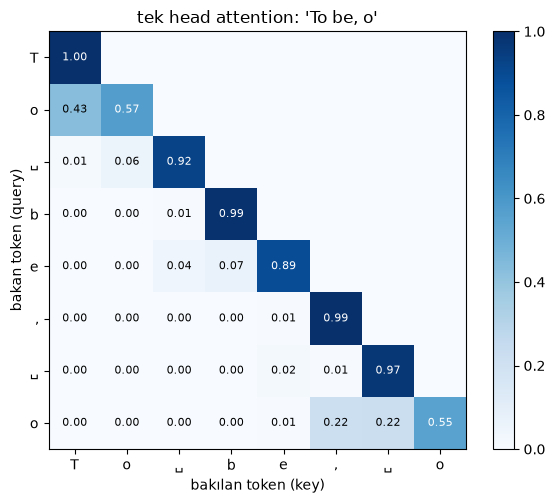

In [19]:
sentence = "To be, o"   # block_size = 8 harf
idx = torch.tensor([encode(sentence)])
model.eval()
with torch.no_grad():
    model(idx)
w = model.sa_head.last_wei[0]
labels = [repr(c)[1:-1] if c != ' ' else '␣' for c in sentence]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(w, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(labels)), labels)
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("bakılan token (key)")
ax.set_ylabel("bakan token (query)")
for i in range(len(labels)):
    for j in range(i + 1):
        ax.text(j, i, f"{w[i, j]:.2f}", ha='center', va='center', fontsize=8,
                color='white' if w[i, j] > 0.5 else 'black')
fig.colorbar(im, ax=ax)
ax.set_title(f"tek head attention: {sentence!r}")
plt.tight_layout()
plt.show()

In [20]:
# rastgele pek çok val parçasında ortalama: geriye uzaklığa göre ağırlık
torch.manual_seed(0)
xb, _ = get_batch('val')
with torch.no_grad():
    model(xb)
W = model.sa_head.last_wei   # (B,T,T)
T = W.shape[-1]
by_dist = torch.zeros(T)
counts = torch.zeros(T)
for i in range(T):
    for j in range(i + 1):
        by_dist[i - j] += W[:, i, j].sum()
        counts[i - j] += W.shape[0]
for d in range(T):
    print(f"{d} harf geriye: ortalama ağırlık {by_dist[d] / counts[d]:.3f}")
_ = model.train()

0 harf geriye: ortalama ağırlık 0.852
1 harf geriye: ortalama ağırlık 0.140
2 harf geriye: ortalama ağırlık 0.027
3 harf geriye: ortalama ağırlık 0.007
4 harf geriye: ortalama ağırlık 0.002
5 harf geriye: ortalama ağırlık 0.001
6 harf geriye: ortalama ağırlık 0.001
7 harf geriye: ortalama ağırlık 0.000


**Ne görüyorum?** Üst üçgen boş, hiçbir harf ileriye bakmıyor. Köşegen çok koyu: çoğu harf ağırlığının %90'ından fazlasını kendisine veriyor (`b` 0.99, `,` 0.99). Ortalama tablosu da aynı şeyi söylüyor: ağırlığın %85'i 0 harf geriye, %14'ü 1 harf geriye gidiyor, 3 harften öncesi neredeyse hiç kullanılmıyor.

İlginç satır sonuncusu: `, o` içindeki `o` ağırlığının 0.55'ini kendisine, 0.22'sini boşluğa ve 0.22'sini virgüle veriyor. Yani bu `o`'nun yeni bir kelimenin ilk harfi olduğunu öğreniyor; kelime ortasındaki bir `o`'dan sonra gelen harf dağılımı ile kelime başındaki `o`'dan sonraki farklı. İkinci satırdaki `o` da `T`'ye 0.43 bakıyor: büyük harfle başlayan bir kelimenin ikinci harfi olduğunu topluyor. Tek head ve 32 boyutlu küçük bir model olduğu için uzağa bakmıyor, kısa bağlamdan (kendisi + 1-2 harf) en çok fayda sağlayan deseni öğrenmiş.

## Ek (b): tril maskesini kaldırırsak

In [21]:
torch.manual_seed(1337)
model_nomask = SingleHeadModel(causal=False)
nomask_losses = train(model_nomask, max_iters=10000, lr=1e-3)
nomask_val = nomask_losses['val']
print()
print(f"{'model':<26}{'val loss':>10}")
print(f"{'bigram':<26}{bigram_val:>10.4f}")
print(f"{'1 head (maskeli)':<26}{head_val:>10.4f}")
print(f"{'1 head (maskesiz)':<26}{nomask_val:>10.4f}")

adım     0: train 4.2000, val 4.2027


adım  1000: train 0.4474, val 0.4463


adım  2000: train 0.4223, val 0.4199


adım  3000: train 0.4106, val 0.4107


adım  4000: train 0.3993, val 0.4003


...

adım  6000: train 0.3926, val 0.3972


adım  7000: train 0.3834, val 0.3863


adım  8000: train 0.3756, val 0.3796


adım  9000: train 0.3810, val 0.3796


adım  9999: train 0.3778, val 0.3743

model                       val loss
bigram                        2.4764
1 head (maskeli)              2.3757
1 head (maskesiz)             0.3760


In [22]:
torch.manual_seed(1337)
print(decode(model_nomask.generate(torch.zeros((1,1), dtype=torch.long), max_new_tokens=300)[0].tolist()))


SSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSTSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSS


**Sonuç.** Maskesiz modelin val loss'u 0.376'ya düştü (maskeli 2.376, bigram 2.476), ama ürettiği metin sadece `SSSSSS...`. Bu sahte bir başarı. Maske yokken t pozisyonu, t+1'deki harfe, yani tam da tahmin etmesi gereken hedefe bakabiliyor. `y[t] = x[t+1]` olduğu için model "bir sonraki token'ın değerini kopyala" diye kopya çekmeyi öğreniyor. Loss'un tam sıfır olmamasının sebebi her parçanın son pozisyonu: orada sağda harf yok, kopya çekilemiyor (8 pozisyondan 1'i).

Metin üretirken ise gelecek yok: son pozisyondaki harfin sağında bakabileceği bir harf olmadığı için kopya çekebileceği bilgi de yok. Üstelik üretimde girdi her adımda değişen uzunlukta ve son pozisyon artık "sağında kopyalanacak harf olan" bir pozisyon gibi davranıyor; model kendi girdisindeki harfi geri kopyalıyor, o harf girdiye ekleniyor, sonra yine onu kopyalıyor. `S` bir kez çıkınca bu döngüye giriyor ve hep `S` üretiyor. Model eğitimde hep cevabı görerek tahmin yaptığı için gerçekten tahmin etmeyi öğrenmemiş, ürettiği metin bigram'dan bile kötü. Düşük val loss burada modelin iyi olduğunu değil, val ölçümünün de aynı kopyaya açık olduğunu gösteriyor. Dil modeli eğitirken maske bu yüzden zorunlu.